Word cloud

In [ ]:
%pip install wordcloud

In [ ]:

"""Word cloud of the 'keywords' field from the Rassegna bibliographic dataset."""

import json
from collections import Counter

import matplotlib.pyplot as plt
from wordcloud import WordCloud

# --- Load data ---------------------------------------------------------
with open("Shared_folder/df_merged.json", encoding="utf-8") as f:
    data = json.load(f)

# --- Extract and count keywords ----------------------------------------
counter = Counter()
for entry in data:
    kw = entry.get("keywords")
    if not kw:
        continue
    # Normalize: string → split on commas; list → use as-is
    phrases = kw.split(",") if isinstance(kw, str) else kw
    for phrase in phrases:
        if not isinstance(phrase, str):
            continue
        phrase = phrase.strip().lower()
        if phrase:
            counter[phrase] += 1

print(f"{len(counter)} unique keywords, top 20:")
for phrase, n in counter.most_common(20):
    print(f"  {n:4d}  {phrase}")

# --- Build word cloud from frequencies ---------------------------------
wc = WordCloud(
    width=1600,
    height=900,          # 16:9 for slides
    background_color="white",
    colormap="viridis",
    max_words=150,
    prefer_horizontal=0.9,
    collocations=False,  # irrelevant here since we pass frequencies
).generate_from_frequencies(counter)

plt.figure(figsize=(16, 9))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig("keywords_wordcloud.png", dpi=200, bbox_inches="tight")
plt.show()


Wordcloud per year

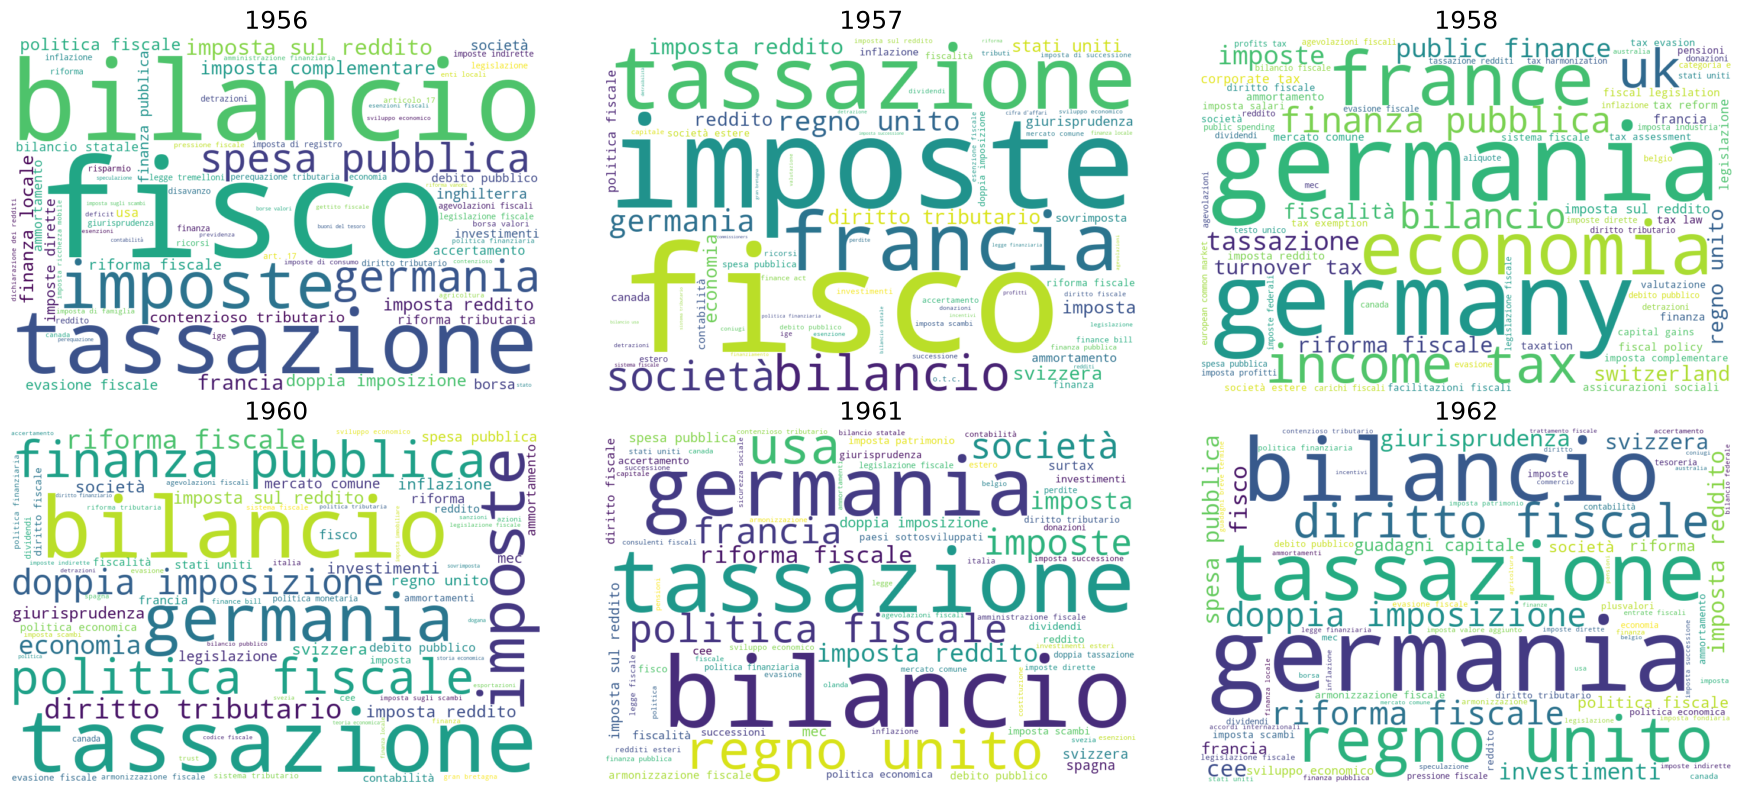

In [8]:
"""One word cloud per source_year, small-multiples grid."""

import json
import math
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
from wordcloud import WordCloud

with open("Shared_folder/df_merged.json", encoding="utf-8") as f:
    data = json.load(f)

# --- Count keywords per year -------------------------------------------
by_year = defaultdict(Counter)
for entry in data:
    kw = entry.get("keywords")
    year = entry.get("source_year")
    if not kw or year is None:
        continue
    phrases = kw.split(",") if isinstance(kw, str) else kw
    for phrase in phrases:
        if not isinstance(phrase, str):
            continue
        phrase = phrase.strip().lower()
        if phrase:
            by_year[int(year)][phrase] += 1

years = sorted(by_year)

# --- Grid of word clouds ------------------------------------------------
ncols = 3
nrows = math.ceil(len(years) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, year in zip(axes, years):
    wc = WordCloud(
        width=900, height=600,
        background_color="white",
        colormap="viridis",
        max_words=75,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(by_year[year])
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(str(year), fontsize=18)
    ax.axis("off")

# Hide unused axes
for ax in axes[len(years):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("keywords_wordcloud_by_year.png", dpi=200, bbox_inches="tight")
plt.show()

Maps

In [ ]:
%pip install geopandas

In [17]:
SHAPEFILE_PATH = "Shared_folder/geodata/geoBoundariesCGAZ_ADM0.shp"

world = gpd.read_file(SHAPEFILE_PATH)

# how many, and what columns exist
print(world.shape)
print(world.columns)

# all country names, alphabetically
print(sorted(world["shapeName"]))

(218, 4)
Index(['shapeGroup', 'shapeType', 'shapeName', 'geometry'], dtype='str')
['Abyei', 'Afghanistan', 'Aksai Chin', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antarctica', 'Antigua & Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia & Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma', 'Burundi', 'CH-IN', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Rep', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo, Dem Rep of the', 'Congo, Rep of the', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Demchok', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Dragonja', 'Dramana-Shakatoe', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Ethiopia', 'Falkland Islands (UK)', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia, The', 'Gaza 


Share of articles by language (% of entries with known language):
language_clean
Italian       40.41
English       27.51
German        20.79
French         9.40
Spanish        1.73
Dutch          0.13
Portuguese     0.04

Entries with missing/unknown language: 748 of 5376

Saved language_map.png and language_map.pdf


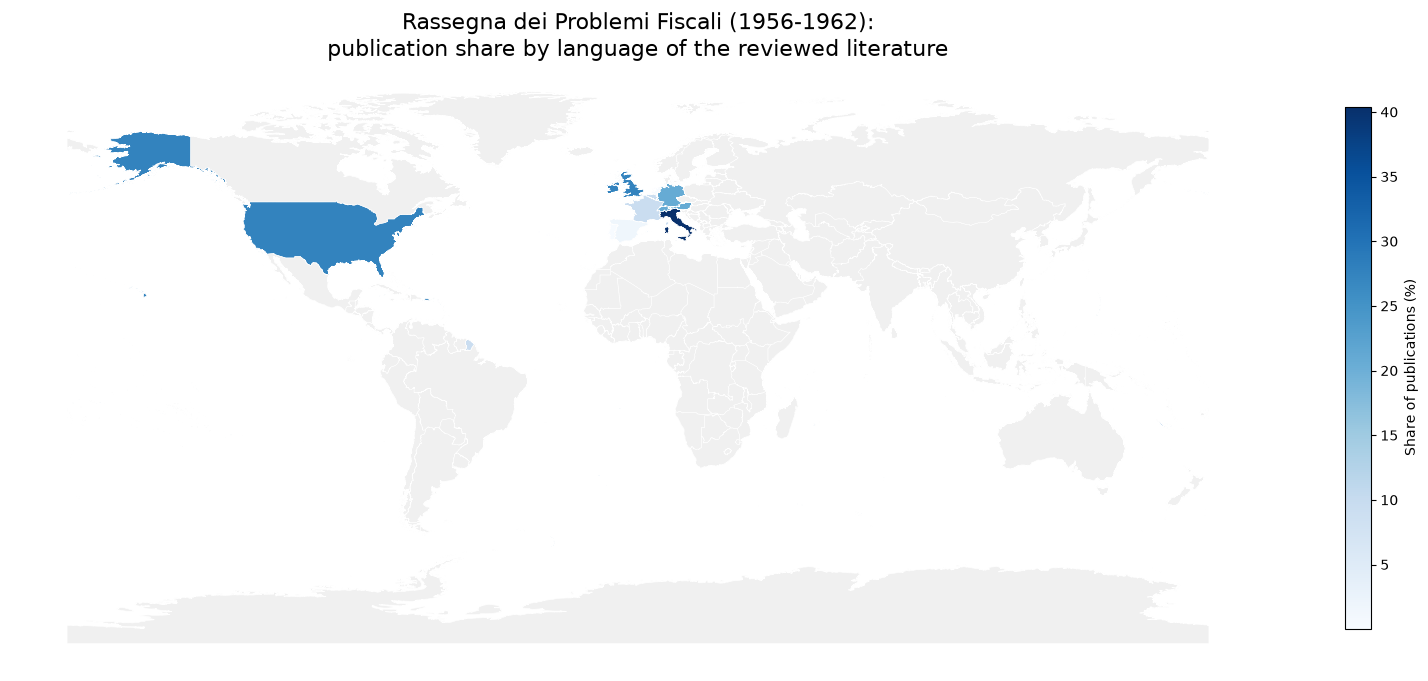

In [18]:
"""
Language shares and world map of publication languages
Rassegna dei Problemi Fiscali bibliographic dataset (1956-1962)

1. Normalizes the messy `language` column (Italian + English labels, mixed case)
   and computes the share of articles per language.
2. Shades countries on a world map (world.shp) by the share of publications
   in that country's main language.

Requires: pandas, geopandas, matplotlib
"""

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Paths - adjust as needed
# ----------------------------------------------------------------------
DATA_PATH = "Shared_folder/df_merged.json"
SHAPEFILE_PATH = "Shared_folder/geodata/geoBoundariesCGAZ_ADM0.shp"
NAME_COL = "shapeName"  # column in world.shp holding country names (Natural Earth: NAME or ADMIN)


#unzip the shapefile if it is in a zip archive
import zipfile
with zipfile.ZipFile("Shared_folder/geodata.zip") as z:
    z.extractall("Shared_folder/geodata")

# ----------------------------------------------------------------------
# 1. Load and normalize languages
# ----------------------------------------------------------------------
df = pd.read_json(DATA_PATH)

# The Gemini NER output mixes Italian and English language labels with
# inconsistent capitalization -> map everything to a canonical English name.
lang_map = {
    "italian": "Italian", "italiano": "Italian",
    "english": "English", "inglese": "English",
    "german": "German", "tedesco": "German",
    "french": "French", "francese": "French",
    "spanish": "Spanish", "spagnolo": "Spanish",
    "dutch": "Dutch", "olandese": "Dutch",
    "portuguese": "Portuguese", "portoghese": "Portuguese",
}

df["language_clean"] = (
    df["language"].astype("string").str.strip().str.lower().map(lang_map)
)

n_unmapped = df["language_clean"].isna().sum() - df["language"].isna().sum()
if n_unmapped > 0:
    print(f"Warning: {n_unmapped} non-missing language values not in lang_map:")
    print(
        df.loc[df["language_clean"].isna() & df["language"].notna(), "language"]
        .str.strip().str.lower().value_counts()
    )

# ----------------------------------------------------------------------
# 2. Language shares (among entries with a known language)
# ----------------------------------------------------------------------
lang_counts = df["language_clean"].value_counts()
lang_shares = (lang_counts / lang_counts.sum() * 100).round(2)

print("\nShare of articles by language (% of entries with known language):")
print(lang_shares.to_string())
print(f"\nEntries with missing/unknown language: {df['language_clean'].isna().sum()} "
      f"of {len(df)}")

# ----------------------------------------------------------------------
# 3. Map languages to countries
# ----------------------------------------------------------------------
# Each country listed gets the FULL share of its language (the share is
# not split between countries). Edit to taste - e.g. drop the US if you
# think "English" in a 1950s European fiscal journal means mostly the UK.
# Names must match the NAME_COL values in your shapefile.
lang_to_countries = {
    "Italian": ["Italy"],
    "English": ["United Kingdom", "United States", "Ireland"],
    "German": ["Germany", "Austria", "Switzerland"],
    "French": ["France", "Belgium", "Luxembourg"],
    "Spanish": ["Spain"],
    "Dutch": ["Netherlands"],
    "Portuguese": ["Portugal"],
}

country_share = {}
for lang, countries in lang_to_countries.items():
    for c in countries:
        country_share[c] = country_share.get(c, 0) + lang_shares.get(lang, 0)

shares_df = pd.DataFrame(
    {"country": list(country_share.keys()), "pub_share": list(country_share.values())}
)

# ----------------------------------------------------------------------
# 4. Plot the choropleth
# ----------------------------------------------------------------------
world = gpd.read_file(SHAPEFILE_PATH)

missing = set(shares_df["country"]) - set(world[NAME_COL])
if missing:
    print(f"\nWarning: countries not found in shapefile: {missing}")
    print(f"Check the values of world['{NAME_COL}'].")

world = world.merge(shares_df, left_on=NAME_COL, right_on="country", how="left")

fig, ax = plt.subplots(figsize=(16, 9))
world.plot(
    column="pub_share",
    cmap="Blues",           # darker = more publications
    legend=True,
    legend_kwds={"label": "Share of publications (%)", "shrink": 0.6},
    missing_kwds={"color": "#f0f0f0", "edgecolor": "white"},
    edgecolor="white",
    linewidth=0.4,
    ax=ax,
)
ax.set_axis_off()
ax.set_title(
    "Rassegna dei Problemi Fiscali (1956-1962):\n"
    "publication share by language of the reviewed literature",
    fontsize=16,
)

#ax.set_xlim(-12, 35)   # longitude: Atlantic coast to western Russia
#ax.set_ylim(34, 62)    # latitude: Mediterranean to Scandinavia

plt.tight_layout()
plt.savefig("language_map.png", dpi=200, bbox_inches="tight")
plt.savefig("language_map.pdf", bbox_inches="tight")  # for LaTeX/Beamer
print("\nSaved language_map.png and language_map.pdf")
plt.show()

Network

In [30]:
%pip install scipy

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ------ --------------------------------- 5.5/36.6 MB 28.4 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/36.6 MB 28.7 MB/s eta 0:00:01
   -------------------- ------------------- 18.6/36.6 MB 30.2 MB/s eta 0:00:01
   --------------------------- ------------ 24.9/36.6 MB 30.6 MB/s eta 0:00:01
   --------------------------------- ------ 30.9/36.6 MB 30.0 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 30.2 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 26.7 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


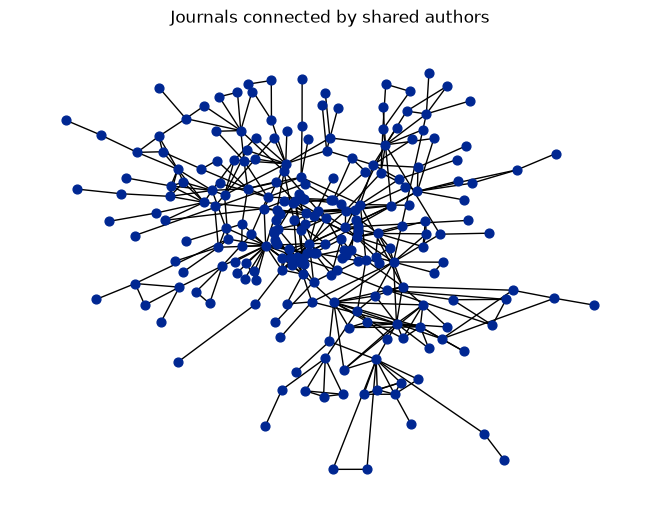

In [49]:
"""Minimal journal network from the Rassegna dataset (didactic version)."""
import pandas, networkx, matplotlib.pyplot 
from itertools import combinations

df = pandas.read_json("Shared_folder/df_merged.json")          # 1. load
df = df.dropna(subset=["author", "journal"])               # 2. keep usable rows

G = networkx.Graph()                                             # 3. empty graph
for author, groups in df.groupby("author"):                   # 4. one author at a time
    for j1, j2 in combinations(groups["journal"].unique(), 2):  # every journal pair
        if G.has_edge(j1, j2):
            G[j1][j2]["weight"] += 1                       # seen before: count up
        else:
            G.add_edge(j1, j2, weight=1)                   # new connection

G.remove_nodes_from(list(networkx.isolates(G)))                  # 5. drop lonely journals

#The center of our story:
pos = networkx.kamada_kawai_layout(G)                            # 6. compute positions

networkx.draw(G, pos, node_color="#002792", edge_color="black",
        node_size=40, with_labels=False)                   # 7. draw
matplotlib.pyplot.title("Journals connected by shared authors")
matplotlib.pyplot.show()

Nicer version

Journals kept: 241 of 436 (threshold: >= 2 articles)
Nodes: 166, edges: 276, isolated journals removed: 75
Saved journal_network_3.png


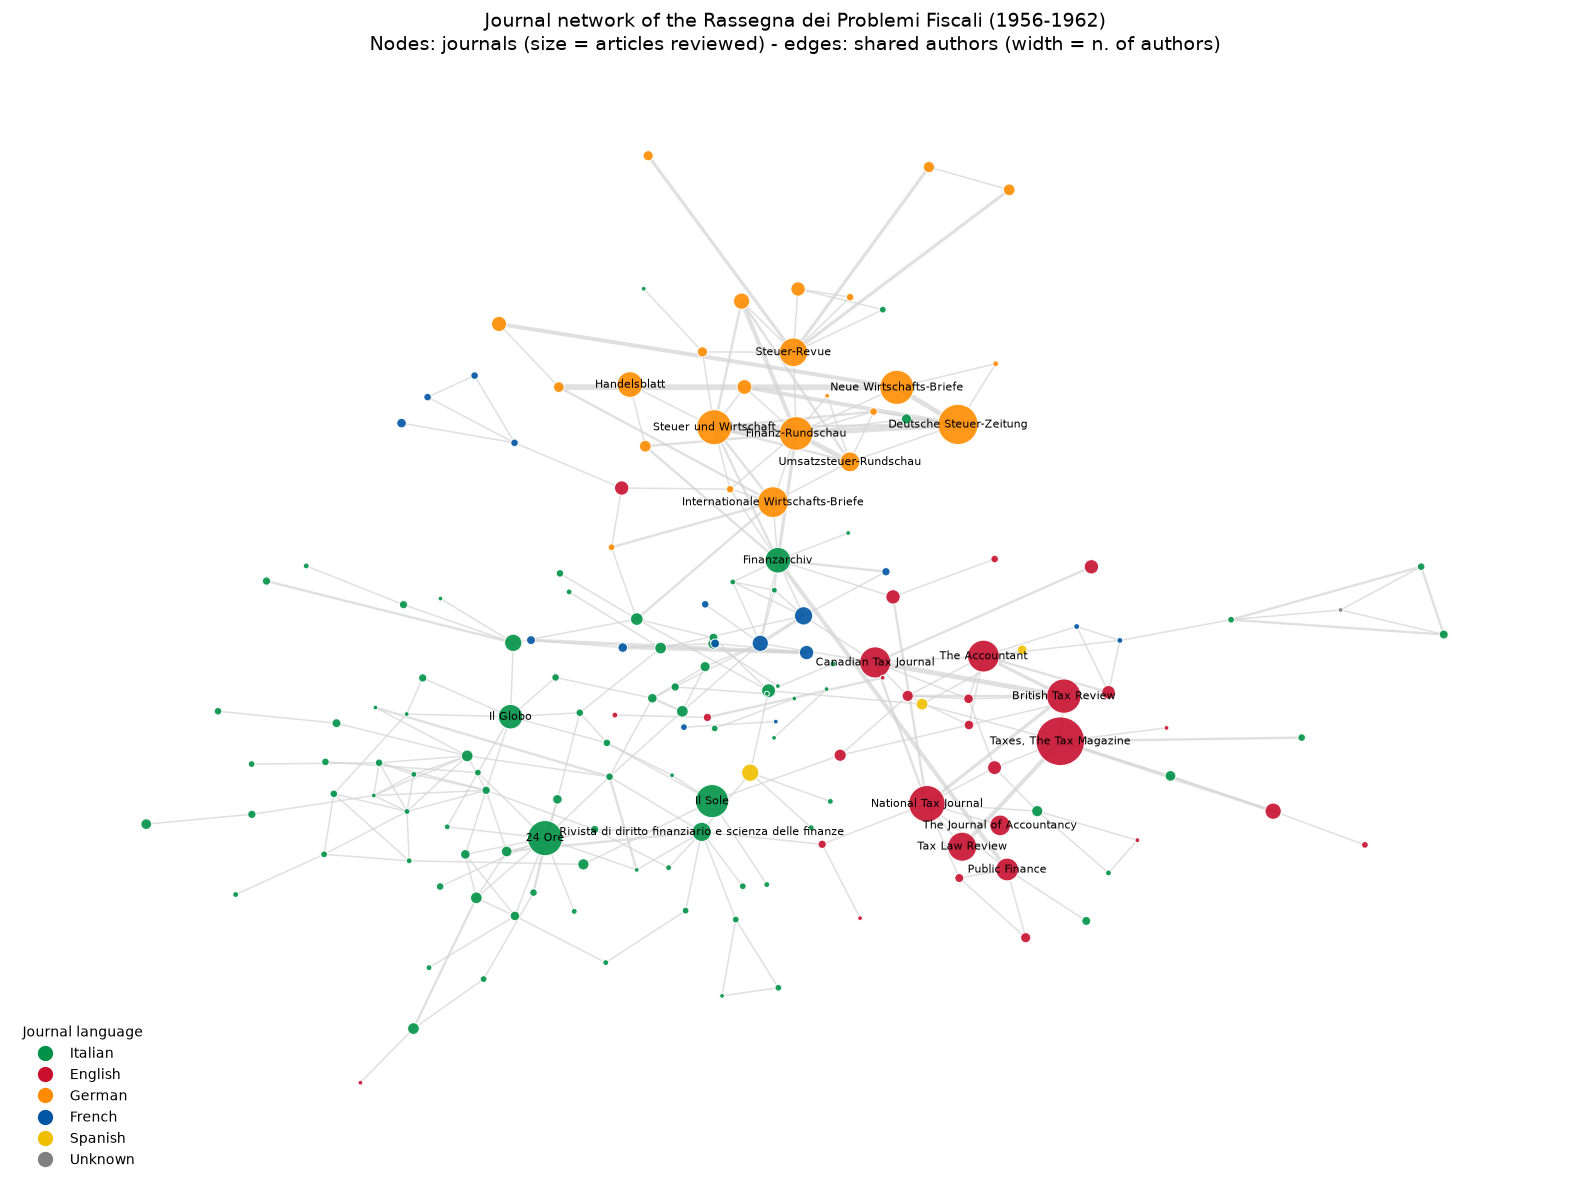


Most connected journals (weighted degree):
    38  Finanz-Rundschau  [German]
    26  Steuer und Wirtschaft  [German]
    21  Deutsche Steuer-Zeitung  [German]
    21  Finanzarchiv  [Italian]
    17  Neue Wirtschafts-Briefe  [German]
    15  British Tax Review  [English]
    15  Steuer-Revue  [German]
    14  Taxes, The Tax Magazine  [English]
    14  National Tax Journal  [English]
    14  Canadian Tax Journal  [English]

Cross-language edges: 55 of 276
  Finanzarchiv <-> Public Finance (4 shared author(s): E. Alexander-Katz, H. Brochier, P. Senf...)
  Finanz-Rundschau <-> Finanzarchiv (3 shared author(s): G. Gast, G. Schmölders, H. Flick...)
  Taxes, The Tax Magazine <-> Taxes. The Tax Magazine (2 shared author(s): A.M. Controll, M.K. Leiter...)
  Steuer und Wirtschaft <-> Finanzarchiv (2 shared author(s): F. Klein, H. Flick...)
  Internationale Wirtschafts-Briefe <-> Diritto e pratica tributaria (2 shared author(s): S. Bianchi, W. Timm...)


In [37]:
"""
Author-journal network
Rassegna dei Problemi Fiscali bibliographic dataset (1956-1962)

Journals are nodes; an edge connects two journals whenever at least one
author published in both. Edge width = number of shared authors.
Node color = (dominant) language of the journal; node size = number of
articles reviewed from that journal.

Requires: pandas, networkx, matplotlib
"""

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# ----------------------------------------------------------------------
# Paths / parameters - adjust as needed
# ----------------------------------------------------------------------
DATA_PATH = "Shared_folder/df_merged.json"
MIN_ARTICLES = 2   # keep only journals with at least this many articles
                   # (436 journals is unreadable; this trims the long tail)

# ----------------------------------------------------------------------
# 1. Load, normalize language, keep rows with author AND journal
# ----------------------------------------------------------------------
df = pd.read_json(DATA_PATH)

lang_map = {
    "italian": "Italian", "italiano": "Italian",
    "english": "English", "inglese": "English",
    "german": "German", "tedesco": "German",
    "french": "French", "francese": "French",
    "spanish": "Spanish", "spagnolo": "Spanish",
    "dutch": "Dutch", "olandese": "Dutch",
    "portuguese": "Portuguese", "portoghese": "Portuguese",
}
df["language_clean"] = (
    df["language"].astype("string").str.strip().str.lower().map(lang_map)
)

sub = df.dropna(subset=["author", "journal"]).copy()
sub["author"] = sub["author"].astype(str).str.strip()
sub["journal"] = sub["journal"].astype(str).str.strip()
sub = sub[~sub["author"].str.lower().isin(["null", "none", ""])]

# ----------------------------------------------------------------------
# 2. Journal-level attributes: article count, dominant language
# ----------------------------------------------------------------------
journal_size = sub["journal"].value_counts()
journal_lang = (
    sub.groupby("journal")["language_clean"]
    .agg(lambda s: s.mode().iloc[0] if s.notna().any() else "Unknown")
)

keep = journal_size[journal_size >= MIN_ARTICLES].index
sub = sub[sub["journal"].isin(keep)]
print(f"Journals kept: {len(keep)} of {journal_size.size} "
      f"(threshold: >= {MIN_ARTICLES} articles)")

# ----------------------------------------------------------------------
# 3. Build the graph: journals = nodes, shared authors = edges
# ----------------------------------------------------------------------
G = nx.Graph()
for j in keep:
    G.add_node(j, size=int(journal_size[j]), language=journal_lang.get(j, "Unknown"))

# For each author, connect every pair of journals they appear in
for author, grp in sub.groupby("author"):
    journals = sorted(grp["journal"].unique())
    for j1, j2 in combinations(journals, 2):
        if G.has_edge(j1, j2):
            G[j1][j2]["weight"] += 1
            G[j1][j2]["authors"].append(author)
        else:
            G.add_edge(j1, j2, weight=1, authors=[author])

# Drop isolated journals (no shared authors with anyone)
isolates = list(nx.isolates(G))
G.remove_nodes_from(isolates)
print(f"Nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}, "
      f"isolated journals removed: {len(isolates)}")

# ----------------------------------------------------------------------
# 4. Plot
# ----------------------------------------------------------------------
lang_colors = {
    "Italian": "#009246",   # your usual country palette
    "English": "#C8102E",
    "German": "darkorange",
    "French": "#0055A4",
    "Spanish": "#F1BF00",
    "Dutch": "#FF7F50",
    "Portuguese": "#006600",
    "Unknown": "grey",
}

#pos = nx.spring_layout(G, k=0.6, weight="weight", seed=42)

pos = nx.kamada_kawai_layout(G)


node_colors = [lang_colors[G.nodes[n]["language"]] for n in G.nodes]
node_sizes = [G.nodes[n]["size"] * 6 for n in G.nodes]
edge_widths = [0.5 + 0.6 * G[u][v]["weight"] for u, v in G.edges]

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color="lightgrey",
                       alpha=0.7, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       edgecolors="white", linewidths=0.8, alpha=0.9, ax=ax)

# Label only the larger journals to keep the plot readable
label_nodes = {n: n for n in G.nodes if G.nodes[n]["size"] >= 30}
nx.draw_networkx_labels(G, pos, labels=label_nodes, font_size=8, ax=ax)

# Legend
handles = [plt.Line2D([], [], marker="o", linestyle="", color=c, label=l,
                      markersize=10)
           for l, c in lang_colors.items()
           if l in {G.nodes[n]["language"] for n in G.nodes}]
ax.legend(handles=handles, title="Journal language", loc="lower left",
          frameon=False)

ax.set_axis_off()
ax.set_title(
    "Journal network of the Rassegna dei Problemi Fiscali (1956-1962)\n"
    "Nodes: journals (size = articles reviewed) - "
    "edges: shared authors (width = n. of authors)",
    fontsize=14,
)

plt.tight_layout()
plt.savefig("journal_network_3.png", dpi=200, bbox_inches="tight")
print("Saved journal_network_3.png")
plt.show()

# ----------------------------------------------------------------------
# 5. A few network statistics for the paper/slides
# ----------------------------------------------------------------------
deg = dict(G.degree(weight="weight"))
top = sorted(deg.items(), key=lambda x: -x[1])[:10]
print("\nMost connected journals (weighted degree):")
for j, d in top:
    print(f"  {d:4d}  {j}  [{G.nodes[j]['language']}]")

# Cross-language edges: bridges between linguistic communities
cross = [(u, v, d) for u, v, d in G.edges(data=True)
         if G.nodes[u]["language"] != G.nodes[v]["language"]]
print(f"\nCross-language edges: {len(cross)} of {G.number_of_edges()}")
for u, v, d in sorted(cross, key=lambda x: -x[2]["weight"])[:5]:
    print(f"  {u} <-> {v} ({d['weight']} shared author(s): "
          f"{', '.join(d['authors'][:3])}...)")

Vector

In [ ]:
%pip install pyvis

In [40]:
"""
Interactive author-journal network (drag + zoom)
Rassegna dei Problemi Fiscali bibliographic dataset (1956-1962)

Same network as journal_network_3.png, but rendered with pyvis to a
standalone HTML file: open it in any browser, drag nodes with the mouse,
zoom with the scroll wheel, hover for tooltips (articles, language,
shared authors on edges).

Requires: pandas, networkx, pyvis
    pip install pyvis          (or: conda install -c conda-forge pyvis)
"""

import pandas as pd
import networkx as nx
from itertools import combinations
from pyvis.network import Network

# ----------------------------------------------------------------------
# Paths / parameters
# ----------------------------------------------------------------------
DATA_PATH = "Shared_folder/df_merged.json"
OUT_HTML = "journal_network_interactive.html"
MIN_ARTICLES = 2

# ----------------------------------------------------------------------
# 1-3. Data pipeline: identical to the static script
# ----------------------------------------------------------------------
df = pd.read_json(DATA_PATH)

lang_map = {
    "italian": "Italian", "italiano": "Italian",
    "english": "English", "inglese": "English",
    "german": "German", "tedesco": "German",
    "french": "French", "francese": "French",
    "spanish": "Spanish", "spagnolo": "Spanish",
    "dutch": "Dutch", "olandese": "Dutch",
    "portuguese": "Portuguese", "portoghese": "Portuguese",
}
df["language_clean"] = (
    df["language"].astype("string").str.strip().str.lower().map(lang_map)
)

sub = df.dropna(subset=["author", "journal"]).copy()
sub["author"] = sub["author"].astype(str).str.strip()
sub["journal"] = sub["journal"].astype(str).str.strip()
sub = sub[~sub["author"].str.lower().isin(["null", "none", ""])]

journal_size = sub["journal"].value_counts()
journal_lang = (
    sub.groupby("journal")["language_clean"]
    .agg(lambda s: s.mode().iloc[0] if s.notna().any() else "Unknown")
)

keep = journal_size[journal_size >= MIN_ARTICLES].index
sub = sub[sub["journal"].isin(keep)]
print(f"Journals kept: {len(keep)} of {journal_size.size} "
      f"(threshold: >= {MIN_ARTICLES} articles)")

G = nx.Graph()
for j in keep:
    G.add_node(j, size=int(journal_size[j]),
               language=journal_lang.get(j, "Unknown"))

for author, grp in sub.groupby("author"):
    journals = sorted(grp["journal"].unique())
    for j1, j2 in combinations(journals, 2):
        if G.has_edge(j1, j2):
            G[j1][j2]["weight"] += 1
            G[j1][j2]["authors"].append(author)
        else:
            G.add_edge(j1, j2, weight=1, authors=[author])

isolates = list(nx.isolates(G))
G.remove_nodes_from(isolates)
print(f"Nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}, "
      f"isolated journals removed: {len(isolates)}")

# ----------------------------------------------------------------------
# 4. Interactive plot with pyvis
# ----------------------------------------------------------------------
lang_colors = {
    "Italian": "#009246",
    "English": "#C8102E",
    "German": "darkorange",
    "French": "#0055A4",
    "Spanish": "#F1BF00",
    "Dutch": "#FF7F50",
    "Portuguese": "#006600",
    "Unknown": "grey",
}

net = Network(
    height="900px", width="100%",
    bgcolor="white", font_color="black",
    notebook=False,           # set True if running inside Jupyter
    cdn_resources="in_line",  # self-contained HTML, works offline
)

# Add nodes manually (rather than net.from_nx) for full control
for n, attrs in G.nodes(data=True):
    n_articles = attrs["size"]
    lang = attrs["language"]
    net.add_node(
        n,
        label=n if n_articles >= 30 else " ",  # label big journals only
        title=f"{n}\n{n_articles} articles - {lang}",  # hover tooltip
        color=lang_colors[lang],
        # pyvis 'size' is a radius in px; sqrt keeps big journals from
        # dwarfing everything (matplotlib node_size is an area, this isn't)
        size=6 + 2.5 * (n_articles ** 0.5),
    )

for u, v, d in G.edges(data=True):
    shared = ", ".join(sorted(set(d["authors"])))
    net.add_edge(
        u, v,
        value=d["weight"],       # 'value' scales edge width automatically
        title=f"{d['weight']} shared author(s): {shared}",
        color="lightgrey",
    )

# Physics: ForceAtlas2 gives a nice interactive feel; nodes stay where
# you drag them once the simulation settles. Tweak sliders live via the
# physics button panel at the bottom of the page.
net.force_atlas_2based(
    gravity=-40, central_gravity=0.005,
    spring_length=120, spring_strength=0.06, damping=0.5,
)
net.show_buttons(filter_=["physics"])

net.write_html(OUT_HTML, open_browser=False)
print(f"Saved {OUT_HTML} - open it in your browser.")

Journals kept: 241 of 436 (threshold: >= 2 articles)
Nodes: 166, edges: 276, isolated journals removed: 75
Saved journal_network_interactive.html - open it in your browser.
